# Verification: Gardner et al. (2000) toggle switch models

Verify `#@figure:` claims in both the base model and the IPTG variant
against independent Python/SciPy solutions of Box 1 Eq. (1).

**Claims verified:**
1. Base model bistability demo → Fig. 5a theoretical curves
2. Base model bifurcation scan → Fig. 2c
3. IPTG variant titration scan → Fig. 5a (theory + experimental data)

In [1]:
import subprocess, os
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

os.chdir(os.path.dirname(os.path.abspath("__file__")))

## Independent implementation of Box 1, Eq. (1)

In [2]:
def toggle_ode(t, y, alpha_1, alpha_2, beta, gamma):
    """Box 1, Eq. (1) in Gardner et al. (2000)."""
    u, v = y
    du = alpha_1 / (1 + v**beta) - u
    dv = alpha_2 / (1 + u**gamma) - v
    return [du, dv]


def toggle_ode_iptg(t, y, alpha_1, alpha_2, beta, gamma, K, eta, IPTG):
    """Eq. (1) modified with IPTG induction (Fig. 5a caption)."""
    u, v = y
    du = alpha_1 / (1 + v**beta) - u
    u_eff = u / (1 + IPTG / K)**eta
    dv = alpha_2 / (1 + u_eff**gamma) - v
    return [du, dv]


# Parameters from Fig. 5a caption
P = dict(alpha_1=156.25, alpha_2=15.6, beta=2.5, gamma=1.0,
         K=2.9618e-5, eta=2.0015)

## 1. Base model: bistability demo (Fig. 5a theoretical curves)

In [3]:
# Run base model
BASE = "genetic_switch_gardner2000.bngl"
r = subprocess.run(["bionetgen", "run", "-i", BASE], capture_output=True, text=True)
assert r.returncode == 0, f"BNG failed:\n{r.stderr}"
print("Base model finished.")

# Load BNG output (3-phase bistability demo)
bng = np.loadtxt("genetic_switch_gardner2000_ode.gdat", comments="#")
bng_t, bng_R1, bng_R2 = bng[:, 0], bng[:, 1], bng[:, 2]

# Reproduce in Python: same 3-phase protocol
# Phase 1: (0,0) -> u-dominant, alpha_2=15.6, t=[0,8]
sol1 = solve_ivp(toggle_ode, [0, 8], [0, 0],
                 args=(P["alpha_1"], 15.6, P["beta"], P["gamma"]),
                 dense_output=True, rtol=1e-10, atol=1e-12)

# Phase 2: alpha_2 -> 600, t=[8,12]
sol2 = solve_ivp(toggle_ode, [8, 12], sol1.sol(8),
                 args=(P["alpha_1"], 600.0, P["beta"], P["gamma"]),
                 dense_output=True, rtol=1e-10, atol=1e-12)

# Phase 3: alpha_2 -> 15.6, t=[12,20]
sol3 = solve_ivp(toggle_ode, [12, 20], sol2.sol(12),
                 args=(P["alpha_1"], 15.6, P["beta"], P["gamma"]),
                 dense_output=True, rtol=1e-10, atol=1e-12)

# Evaluate Python solution at BNG time points
py_R1 = np.empty_like(bng_t)
py_R2 = np.empty_like(bng_t)
for i, t in enumerate(bng_t):
    if t <= 8:
        py_R1[i], py_R2[i] = sol1.sol(t)
    elif t <= 12:
        py_R1[i], py_R2[i] = sol2.sol(t)
    else:
        py_R1[i], py_R2[i] = sol3.sol(t)

err_R1 = np.max(np.abs(bng_R1 - py_R1) / np.clip(np.abs(py_R1), 1e-15, None)) * 100
err_R2 = np.max(np.abs(bng_R2 - py_R2) / np.clip(np.abs(py_R2), 1e-15, None)) * 100
print(f"Bistability demo max errors:  R1: {err_R1:.4f}%   R2: {err_R2:.4f}%")

Base model finished.
Bistability demo max errors:  R1: 0.0000%   R2: 0.0001%


## 2. Base model: bifurcation scan (Fig. 2c)

In [4]:
# Load BNG parameter scan (alpha_2 scan)
scan = np.loadtxt("genetic_switch_gardner2000_scan.scan", comments="#")
bng_a2 = scan[:, 0]
bng_scan_R1 = scan[:, 1]
bng_scan_R2 = scan[:, 2]

# The BNG scan runs AFTER the bistability demo chain, so it starts
# from the v-dominant state (R1 low, R2 high). Reproduce this: get
# the v-dominant steady state at alpha_2=15.6, then scan from there.
sol_v = solve_ivp(toggle_ode, [0, 50], [0.33, 11.65],  # near v-dominant
                  args=(P["alpha_1"], 15.6, P["beta"], P["gamma"]),
                  method="BDF", rtol=1e-10, atol=1e-12)
u_v_ss, v_v_ss = sol_v.y[:, -1]
print(f"v-dominant IC: u={u_v_ss:.4f}, v={v_v_ss:.4f}")

py_scan_R1 = np.empty_like(bng_a2)
py_scan_R2 = np.empty_like(bng_a2)
for i, a2 in enumerate(bng_a2):
    sol = solve_ivp(toggle_ode, [0, 20], [u_v_ss, v_v_ss],
                    args=(P["alpha_1"], a2, P["beta"], P["gamma"]),
                    method="BDF", rtol=1e-10, atol=1e-12)
    py_scan_R1[i], py_scan_R2[i] = sol.y[:, -1]

mask = py_scan_R2 > 0.1
err_scan = np.max(np.abs(bng_scan_R2[mask] - py_scan_R2[mask])
                  / py_scan_R2[mask]) * 100
print(f"Bifurcation scan max error (R2): {err_scan:.4f}%")

v-dominant IC: u=0.3324, v=11.7080


Bifurcation scan max error (R2): 0.0105%


## 3. IPTG variant: titration scan (Fig. 5a)

In [5]:
# Run IPTG variant
IPTG_FILE = "genetic_switch_gardner2000_iptg.bngl"
r = subprocess.run(["bionetgen", "run", "-i", IPTG_FILE],
                   capture_output=True, text=True)
assert r.returncode == 0, f"BNG failed:\n{r.stderr}"
print("IPTG variant finished.")

# Load BNG IPTG scan
iptg_scan = np.loadtxt(
    "genetic_switch_gardner2000_iptg_scan.scan", comments="#")
bng_iptg = iptg_scan[:, 0]
bng_iptg_R2 = iptg_scan[:, 2]

# The scan output also has functions if print_functions=>1
# Columns: IPTG, R1, R2, syn_R1, syn_R2, norm_v, exp_gfp_fig5a
bng_norm_v = iptg_scan[:, 5] if iptg_scan.shape[1] > 5 else bng_iptg_R2 / P["alpha_2"]
bng_exp_gfp = iptg_scan[:, 6] if iptg_scan.shape[1] > 6 else None

# Python: solve IPTG-modified ODE to steady state for each [IPTG]
# Start from low-GFP steady state (u-dominant at IPTG=0)
sol0 = solve_ivp(toggle_ode, [0, 50], [0, 0],
                 args=(P["alpha_1"], P["alpha_2"], P["beta"], P["gamma"]),
                 method="BDF", rtol=1e-10, atol=1e-12)
u0_ss, v0_ss = sol0.y[:, -1]

py_iptg_R2 = np.empty_like(bng_iptg)
for i, iptg_val in enumerate(bng_iptg):
    sol = solve_ivp(toggle_ode_iptg, [0, 20], [u0_ss, v0_ss],
                    args=(P["alpha_1"], P["alpha_2"], P["beta"],
                          P["gamma"], P["K"], P["eta"], iptg_val),
                    method="BDF", rtol=1e-10, atol=1e-12)
    py_iptg_R2[i] = sol.y[1, -1]

mask = py_iptg_R2 > 0.1
err_iptg = np.max(np.abs(bng_iptg_R2[mask] - py_iptg_R2[mask])
                  / py_iptg_R2[mask]) * 100
print(f"IPTG scan max error (R2): {err_iptg:.4f}%")

IPTG variant finished.


IPTG scan max error (R2): 0.0001%


## 4. Plots

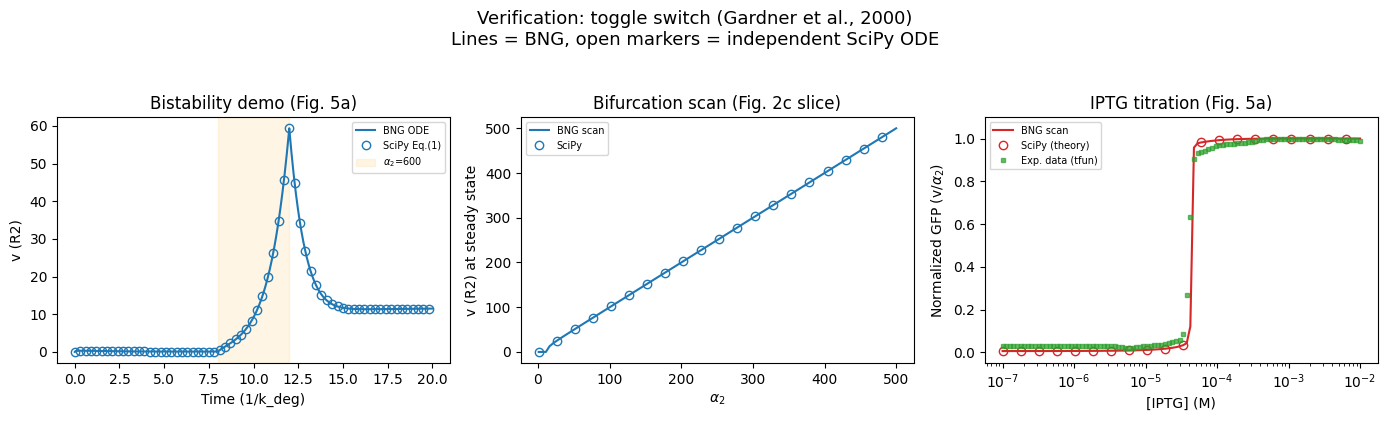

Saved verify_gardner2000.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
every = 15  # subsample for marker visibility

# --- Panel 1: Bistability demo (Fig. 5a) ---
ax = axes[0]
ax.plot(bng_t, bng_R2, "C0-", lw=1.5, label="BNG ODE")
ax.plot(bng_t[::every], py_R2[::every], "o", mfc="none",
        mec="C0", ms=6, label="SciPy Eq.(1)")
ax.axvspan(8, 12, alpha=0.1, color="orange",
           label=r"$\alpha_2$=600")
ax.set_xlabel("Time (1/k_deg)")
ax.set_ylabel("v (R2)")
ax.set_title("Bistability demo (Fig. 5a)")
ax.legend(fontsize=7)

# --- Panel 2: Bifurcation scan (Fig. 2c) ---
ax = axes[1]
ax.plot(bng_a2, bng_scan_R2, "C0-", lw=1.5, label="BNG scan")
ax.plot(bng_a2[::5], py_scan_R2[::5], "o", mfc="none",
        mec="C0", ms=6, label="SciPy")
ax.set_xlabel(r"$\alpha_2$")
ax.set_ylabel("v (R2) at steady state")
ax.set_title("Bifurcation scan (Fig. 2c slice)")
ax.legend(fontsize=7)

# --- Panel 3: IPTG titration (Fig. 5a) ---
ax = axes[2]
py_norm_v = py_iptg_R2 / P["alpha_2"]
ax.semilogx(bng_iptg, bng_norm_v, "C3-", lw=1.5,
            label="BNG scan")
ax.semilogx(bng_iptg[::5], py_norm_v[::5], "o", mfc="none",
            mec="C3", ms=6, label="SciPy (theory)")
if bng_exp_gfp is not None:
    ax.semilogx(bng_iptg, bng_exp_gfp, "s", color="tab:green",
                ms=3, alpha=0.7, label="Exp. data (tfun)")
ax.set_xlabel("[IPTG] (M)")
ax.set_ylabel("Normalized GFP (v/$\\alpha_2$)")
ax.set_title("IPTG titration (Fig. 5a)")
ax.legend(fontsize=7)
ax.set_ylim(-0.05, 1.1)

fig.suptitle(
    "Verification: toggle switch (Gardner et al., 2000)\n"
    "Lines = BNG, open markers = independent SciPy ODE",
    fontsize=13, y=1.04)
fig.tight_layout()
plt.savefig("verify_gardner2000.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved verify_gardner2000.png")